## Cognitive Load Estimation Using Physiological Parameters
Using CLAS (Cognitive Load, Affect, and Stress) dataset: https://ieeexplore.ieee.org/abstract/document/8967457

#### Bimodal 2-level classification

In [1]:
import os
import pandas as pd
import numpy as np

from multimodal_windowing import (
    build_multimodal_windowed_dataset,
    DEFAULT_MULTIMODAL_FEATURE_COLUMNS,
)

# points to CLAS folder 
data_path = "D:/Major Project/CLAS/"

In [2]:
# Define your binary label mapping
label_map = {
    'Baseline': 'LOW',
    'Math Test': 'HIGH',
    'IQ Test': 'HIGH',
    # 'Stroop Test' dropped to keep binary LOW vs HIGH
}

Now, extracting features of 60 particpants

In [3]:
window_seconds = 60
step_seconds = 30
sampling_rate = 256
class_weights = {"LOW": 1, "HIGH": 1}

In [4]:
features_df = build_multimodal_windowed_dataset(
    data_path=data_path.rstrip("/"),
    label_map=label_map,
    sampling_rate=sampling_rate,
    window_seconds=window_seconds,
    step_seconds=step_seconds,
)

print("Windowed ECG+GSR feature table shape:", features_df.shape)
features_df.head()


d:\Major Project\.venv\Lib\site-packages\neurokit2\hrv\hrv_nonlinear.py:544: NeuroKitWarning: DFA_alpha2 related indices will not be calculated. The maximum duration of the windows provided for the long-term correlation is smaller than the minimum duration of windows. Refer to the `scale` argument in `nk.fractal_dfa()` for more information.
  warn(
d:\Major Project\.venv\Lib\site-packages\neurokit2\hrv\hrv_nonlinear.py:544: NeuroKitWarning: DFA_alpha2 related indices will not be calculated. The maximum duration of the windows provided for the long-term correlation is smaller than the minimum duration of windows. Refer to the `scale` argument in `nk.fractal_dfa()` for more information.
  warn(
d:\Major Project\.venv\Lib\site-packages\neurokit2\hrv\hrv_nonlinear.py:544: NeuroKitWarning: DFA_alpha2 related indices will not be calculated. The maximum duration of the windows provided for the long-term correlation is smaller than the minimum duration of windows. Refer to the `scale` argument

Windowed ECG+GSR feature table shape: (32, 23)


,window_start_sample,window_end_sample,window_start_sec,window_end_sec,mean_hr,rmssd,sdnn,pnn50,sd1,sd2,...,Label,ECG File,GSR File,mean_scl,std_scl,mean_phasic,std_phasic,scr_peaks,scr_rate_per_min,Block Type
0,0,15360,0.0,60.0,70.616097,378.150874,363.376412,36.764706,269.410816,441.801767,...,LOW,1_ecg_.csv,1_gsr_ppg_.csv,762.117013,631.196710,-0.110192,1856.824900,1.0,1.0,Baseline
1,0,15360,0.0,60.0,81.348810,27.812994,43.965196,5.000000,19.792393,59.322188,...,HIGH,2_ecg_.csv,2_gsr_ppg_.csv,100.434762,2.290589,0.021066,1.104820,12.0,12.0,Math Test
2,7680,23040,30.0,90.0,80.864696,29.481589,48.969906,8.860759,20.976446,66.342146,...,HIGH,2_ecg_.csv,2_gsr_ppg_.csv,98.907767,0.679239,-0.050565,0.857992,10.0,10.0,Math Test
3,15360,30720,60.0,120.0,76.960739,35.483183,39.136332,16.000000,25.257641,49.342799,...,HIGH,2_ecg_.csv,2_gsr_ppg_.csv,98.195482,1.007557,0.019957,0.696802,12.0,12.0,Math Test
4,23040,38400,90.0,150.0,78.528974,29.337965,34.854278,6.493506,20.843621,42.678994,...,HIGH,2_ecg_.csv,2_gsr_ppg_.csv,97.047173,0.487225,0.009858,0.630915,14.0,14.0,Math Test


In [5]:
all_blocks = []

for participant_id in range(1, 61):
    participant_name = f"Part{participant_id}"
    block_file = os.path.join(data_path, "Block_details", f"{participant_name}_Block_Details.csv")

    if not os.path.exists(block_file):
        print(f"Missing block file for {participant_name}")
        continue

    df = pd.read_csv(block_file)
    df.columns = df.columns.str.strip()
    df["Participant"] = participant_name
    all_blocks.append(df)

blocks_all = pd.concat(all_blocks, ignore_index=True)

print("blocks_all shape:", blocks_all.shape)
print("Participants found:", blocks_all["Participant"].nunique())
blocks_all.head()


Missing block file for Part4
blocks_all shape: (2183, 10)
Participants found: 59


,Block,Block Type,ECG File,EDA&PPG File,Length(s),EDA Quality,ECG Quality,PPG Quality,Unnamed: 8,Participant
0,1,Baseline,1_ecg.csv,1_gsr_ppg_.csv,60.02,2.0,2.0,2.0,NaN,Part1
1,10,Neutral,10_ecg.csv,10_gsr_ppg_.csv,29.99,1.0,2.0,2.0,NaN,Part1
2,11,Video clip,11_ecg.csv,11_gsr_ppg_.csv,60.02,2.0,2.0,2.0,NaN,Part1
3,12,Video clip,12_ecg.csv,12_gsr_ppg_.csv,60.03,2.0,2.0,2.0,NaN,Part1
4,13,Video clip,13_ecg.csv,13_gsr_ppg_.csv,60.01,2.0,2.0,2.0,NaN,Part1


In [6]:
# features_df is already created by the windowed extraction cell above
features_df.head()

,window_start_sample,window_end_sample,window_start_sec,window_end_sec,mean_hr,rmssd,sdnn,pnn50,sd1,sd2,...,Label,ECG File,GSR File,mean_scl,std_scl,mean_phasic,std_phasic,scr_peaks,scr_rate_per_min,Block Type
0,0,15360,0.0,60.0,70.616097,378.150874,363.376412,36.764706,269.410816,441.801767,...,LOW,1_ecg_.csv,1_gsr_ppg_.csv,762.117013,631.196710,-0.110192,1856.824900,1.0,1.0,Baseline
1,0,15360,0.0,60.0,81.348810,27.812994,43.965196,5.000000,19.792393,59.322188,...,HIGH,2_ecg_.csv,2_gsr_ppg_.csv,100.434762,2.290589,0.021066,1.104820,12.0,12.0,Math Test
2,7680,23040,30.0,90.0,80.864696,29.481589,48.969906,8.860759,20.976446,66.342146,...,HIGH,2_ecg_.csv,2_gsr_ppg_.csv,98.907767,0.679239,-0.050565,0.857992,10.0,10.0,Math Test
3,15360,30720,60.0,120.0,76.960739,35.483183,39.136332,16.000000,25.257641,49.342799,...,HIGH,2_ecg_.csv,2_gsr_ppg_.csv,98.195482,1.007557,0.019957,0.696802,12.0,12.0,Math Test
4,23040,38400,90.0,150.0,78.528974,29.337965,34.854278,6.493506,20.843621,42.678994,...,HIGH,2_ecg_.csv,2_gsr_ppg_.csv,97.047173,0.487225,0.009858,0.630915,14.0,14.0,Math Test


In [7]:
print(features_df.shape)
print(features_df["Label"].value_counts())
print(features_df.isna().sum())


(32, 23)
Label
HIGH    21
LOW     11
Name: count, dtype: int64
window_start_sample    0
window_end_sample      0
window_start_sec       0
window_end_sec         0
mean_hr                0
rmssd                  0
sdnn                   0
pnn50                  0
sd1                    0
sd2                    0
sd1_sd2                0
Participant            0
Block                  0
Label                  0
ECG File               0
GSR File               0
mean_scl               0
std_scl                0
mean_phasic            0
std_phasic             0
scr_peaks              0
scr_rate_per_min       0
Block Type             0
dtype: int64


In [8]:
all_labeled = blocks_all[blocks_all["Block Type"].isin(label_map.keys())].copy()
all_labeled["Label"] = all_labeled["Block Type"].map(label_map)

print("Before quality filtering:")
print(all_labeled["Label"].value_counts())

print("\nUnique participants per label:")
print(all_labeled.groupby("Label")["Participant"].nunique())

print("\nBlock types:")
print(all_labeled["Block Type"].value_counts())

Before quality filtering:
Label
HIGH    118
LOW      59
Name: count, dtype: int64

Unique participants per label:
Label
HIGH    59
LOW     59
Name: Participant, dtype: int64

Block types:
Block Type
Baseline     59
Math Test    59
IQ Test      59
Name: count, dtype: int64


In [9]:
all_labeled = blocks_all[blocks_all["Block Type"].isin(label_map.keys())].copy()
all_labeled["Label"] = all_labeled["Block Type"].map(label_map)

print("Before filtering:")
print(all_labeled["Label"].value_counts())

ecg_ok = all_labeled[all_labeled["ECG Quality"] == 2.0]
print("\nAfter ECG quality filter:")
print(ecg_ok["Label"].value_counts())

Before filtering:
Label
HIGH    118
LOW      59
Name: count, dtype: int64

After ECG quality filter:
Label
LOW     44
HIGH    32
Name: count, dtype: int64


#### Clean the ecg feature table

In [10]:
features_df.shape
features_df.isna().sum()
features_df.describe()

,window_start_sample,window_end_sample,window_start_sec,window_end_sec,mean_hr,rmssd,sdnn,pnn50,sd1,sd2,sd1_sd2,Block,mean_scl,std_scl,mean_phasic,std_phasic,scr_peaks,scr_rate_per_min
count,32.000000,32.000000,32.000000,32.000000,32.000000,32.000000,32.000000,32.000000,32.000000,32.000000,32.000000,32.000000,32.000000,32.000000,32.000000,32.000000,32.000000,32.000000
mean,12960.000000,28320.000000,50.625000,110.625000,83.726913,71.200932,80.757174,12.549117,50.644187,98.716787,0.454652,3.343750,403.347979,141.029826,0.708400,99.651251,9.406250,9.406250
std,17166.076073,17166.076073,67.054985,67.054985,11.036095,85.642002,77.083083,12.245131,60.980921,91.378883,0.185275,2.990408,964.943871,491.433109,3.832025,358.028285,4.368947,4.368947
min,0.000000,15360.000000,0.000000,60.000000,67.421440,13.003066,21.224539,0.970874,9.240284,28.683500,0.288991,1.000000,54.122989,0.487225,-1.610095,0.562192,1.000000,1.000000
25%,0.000000,15360.000000,0.000000,60.000000,77.204691,25.914278,41.230010,2.393784,18.446845,53.675260,0.319503,1.000000,83.053371,2.132041,-0.021569,1.070526,6.000000,6.000000
50%,7680.000000,23040.000000,30.000000,90.000000,80.143228,33.753941,50.489922,9.354167,24.022684,67.903875,0.374869,2.000000,102.502344,4.304123,0.003855,2.381259,10.000000,10.000000
75%,23040.000000,38400.000000,90.000000,150.000000,82.875249,82.527401,85.775906,16.666667,58.642699,92.211693,0.548593,8.000000,143.107266,18.483922,0.023014,7.067432,12.250000,12.250000
max,61440.000000,76800.000000,240.000000,300.000000,112.313760,378.150874,363.376412,53.424658,269.410816,441.801767,1.126984,8.000000,5111.026064,2683.872709,21.483724,1856.824900,18.000000,18.000000


In [11]:
feature_cols = DEFAULT_MULTIMODAL_FEATURE_COLUMNS
X = features_df[feature_cols]
y = features_df["Label"]
groups = features_df["Participant"]

#### Build the final ECG modeling table

In [12]:
import numpy as np
import pandas as pd
from sklearn.model_selection import GroupKFold
from sklearn.base import clone
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.dummy import DummyClassifier
from sklearn.metrics import classification_report, confusion_matrix, f1_score

try:
    from sklearn.model_selection import StratifiedGroupKFold
    HAS_STRATIFIED_GROUP_KFOLD = True
except ImportError:
    HAS_STRATIFIED_GROUP_KFOLD = False

modeling_df = features_df[[
    "Participant",
    "Block",
    "Label",
    "window_start_sec",
    "window_end_sec",
    *feature_cols,
]].copy()
modeling_df = modeling_df.replace([np.inf, -np.inf], np.nan).dropna()

# Remove obviously failed feature extractions while keeping plausible physiology.
modeling_df = modeling_df[
    modeling_df["mean_hr"].between(35, 220)
    & modeling_df["rmssd"].between(1, 500)
    & modeling_df["sdnn"].between(1, 500)
    & modeling_df["pnn50"].between(0, 100)
    & modeling_df["sd1"].between(1, 500)
    & modeling_df["sd2"].between(1, 500)
    & modeling_df["sd1_sd2"].between(0, 10)
    & modeling_df["std_scl"].between(0, 1e6)
    & modeling_df["std_phasic"].between(0, 1e6)
    & modeling_df["scr_peaks"].between(0, 500)
    & modeling_df["scr_rate_per_min"].between(0, 500)
].copy()

X = modeling_df[feature_cols]
y = modeling_df["Label"]
groups = modeling_df["Participant"]
metadata = modeling_df[["Participant", "Block", "Label", "window_start_sec", "window_end_sec"]].copy()
labels = ["LOW", "HIGH"]

print("Final ECG+GSR modeling table shape:", modeling_df.shape)
print(modeling_df["Label"].value_counts())
display(modeling_df.head())

Final ECG+GSR modeling table shape: (32, 18)
Label
HIGH    21
LOW     11
Name: count, dtype: int64


,Participant,Block,Label,window_start_sec,window_end_sec,mean_hr,rmssd,sdnn,pnn50,sd1,sd2,sd1_sd2,mean_scl,std_scl,mean_phasic,std_phasic,scr_peaks,scr_rate_per_min
0,Part1,1,LOW,0.0,60.0,70.616097,378.150874,363.376412,36.764706,269.410816,441.801767,0.609800,762.117013,631.196710,-0.110192,1856.824900,1.0,1.0
1,Part1,2,HIGH,0.0,60.0,81.348810,27.812994,43.965196,5.000000,19.792393,59.322188,0.333642,100.434762,2.290589,0.021066,1.104820,12.0,12.0
2,Part1,2,HIGH,30.0,90.0,80.864696,29.481589,48.969906,8.860759,20.976446,66.342146,0.316186,98.907767,0.679239,-0.050565,0.857992,10.0,10.0
3,Part1,2,HIGH,60.0,120.0,76.960739,35.483183,39.136332,16.000000,25.257641,49.342799,0.511881,98.195482,1.007557,0.019957,0.696802,12.0,12.0
4,Part1,2,HIGH,90.0,150.0,78.528974,29.337965,34.854278,6.493506,20.843621,42.678994,0.488381,97.047173,0.487225,0.009858,0.630915,14.0,14.0


In [13]:
print(modeling_df.columns.tolist())

['Participant', 'Block', 'Label', 'window_start_sec', 'window_end_sec', 'mean_hr', 'rmssd', 'sdnn', 'pnn50', 'sd1', 'sd2', 'sd1_sd2', 'mean_scl', 'std_scl', 'mean_phasic', 'std_phasic', 'scr_peaks', 'scr_rate_per_min']


#### Grouped cross-validation baselines

In [14]:
from sklearn.model_selection import GroupKFold
from sklearn.metrics import f1_score, classification_report, confusion_matrix
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
import pandas as pd

##### Cross Validation Splitter


In [15]:

def get_group_splitter(groups, n_splits=5):
    n_groups = groups.nunique()
    n_splits = min(n_splits, n_groups)

    if HAS_STRATIFIED_GROUP_KFOLD:
        from sklearn.model_selection import StratifiedGroupKFold
        return StratifiedGroupKFold(n_splits=n_splits, shuffle=True, random_state=42)

    return GroupKFold(n_splits=n_splits)


##### Model Evaluation

In [16]:
def summarize_predictions(eval_df, labels):
    report = classification_report(
        eval_df["true_label"],
        eval_df["pred_label"],
        labels=labels,
        output_dict=True,
        zero_division=0,
    )
    report_df = pd.DataFrame(report).T
    cm = pd.DataFrame(
        confusion_matrix(eval_df["true_label"], eval_df["pred_label"], labels=labels),
        index=[f"true_{label}" for label in labels],
        columns=[f"pred_{label}" for label in labels],
    )
    return {
        "macro_f1": report_df.loc["macro avg", "f1-score"],
        "weighted_f1": report_df.loc["weighted avg", "f1-score"],
        "report": report_df,
        "confusion_matrix": cm,
    }

def aggregate_to_block_level(prediction_df, labels):
    block_df = prediction_df.copy()

    if {"prob_LOW", "prob_HIGH"}.issubset(block_df.columns):
        grouped = (
            block_df.groupby(["Participant", "Block", "true_label"], as_index=False)[["prob_LOW", "prob_HIGH"]]
            .mean()
        )
        prob_cols = [f"prob_{label}" for label in labels]
        grouped["pred_label"] = grouped[prob_cols].idxmax(axis=1).str.replace("prob_", "", regex=False)
        return grouped

    grouped = (
        block_df.groupby(["Participant", "Block", "true_label", "pred_label"], as_index=False)
        .size()
        .sort_values(["Participant", "Block", "size", "pred_label"], ascending=[True, True, False, True])
    )
    return grouped.drop_duplicates(["Participant", "Block", "true_label"])

def evaluate_model(name, model, X, y, groups, labels, metadata):

    splitter = get_group_splitter(groups)
    fold_results = []
    prediction_rows = []

    for fold, (train_idx, test_idx) in enumerate(splitter.split(X, y, groups), start=1):

        X_train = X.iloc[train_idx]
        X_test = X.iloc[test_idx]
        y_train = y.iloc[train_idx]
        y_test = y.iloc[test_idx]
        test_meta = metadata.iloc[test_idx].reset_index(drop=True)

        fitted_model = clone(model)
        fitted_model.fit(X_train, y_train)
        preds = fitted_model.predict(X_test)

        fold_pred_df = test_meta[["Participant", "Block"]].copy()
        fold_pred_df["fold"] = fold
        fold_pred_df["true_label"] = y_test.reset_index(drop=True)
        fold_pred_df["pred_label"] = preds

        if hasattr(fitted_model, "predict_proba"):
            proba = fitted_model.predict_proba(X_test)
            proba_df = pd.DataFrame(proba, columns=[f"prob_{cls}" for cls in fitted_model.classes_])
            for label in labels:
                col = f"prob_{label}"
                fold_pred_df[col] = proba_df[col] if col in proba_df.columns else 0.0

        prediction_rows.append(fold_pred_df)

        block_fold_df = aggregate_to_block_level(fold_pred_df, labels)

        fold_results.append({
            "fold": fold,
            "window_macro_f1": f1_score(y_test, preds, average="macro", zero_division=0),
            "window_weighted_f1": f1_score(y_test, preds, average="weighted", zero_division=0),
            "block_macro_f1": f1_score(block_fold_df["true_label"], block_fold_df["pred_label"], average="macro", zero_division=0),
            "block_weighted_f1": f1_score(block_fold_df["true_label"], block_fold_df["pred_label"], average="weighted", zero_division=0),
            "test_windows": len(test_idx),
            "test_blocks": len(block_fold_df),
        })

    prediction_df = pd.concat(prediction_rows, ignore_index=True)
    block_prediction_df = aggregate_to_block_level(prediction_df, labels)
    fold_df = pd.DataFrame(fold_results)

    window_metrics = summarize_predictions(prediction_df, labels)
    block_metrics = summarize_predictions(block_prediction_df, labels)

    print(f"\n{name}")
    print("Window Macro F1:", round(window_metrics["macro_f1"], 4))
    print("Window Weighted F1:", round(window_metrics["weighted_f1"], 4))
    print("Block Macro F1:", round(block_metrics["macro_f1"], 4))
    print("Block Weighted F1:", round(block_metrics["weighted_f1"], 4))

    print("\nPer-fold metrics:")
    display(fold_df)

    print("\nWindow-level confusion matrix:")
    display(window_metrics["confusion_matrix"])

    print("\nBlock-level confusion matrix:")
    display(block_metrics["confusion_matrix"])

    print("\nWindow-level classification report:")
    display(window_metrics["report"])

    print("\nBlock-level classification report:")
    display(block_metrics["report"])

    return {
        "model": name,
        "window_macro_f1": window_metrics["macro_f1"],
        "window_weighted_f1": window_metrics["weighted_f1"],
        "window_confusion_matrix": window_metrics["confusion_matrix"],
        "window_report": window_metrics["report"],
        "block_macro_f1": block_metrics["macro_f1"],
        "block_weighted_f1": block_metrics["weighted_f1"],
        "block_confusion_matrix": block_metrics["confusion_matrix"],
        "block_report": block_metrics["report"],
        "fold_metrics": fold_df,
        "window_predictions": prediction_df,
        "block_predictions": block_prediction_df,
    }


##### Models

In [17]:
models = {

    "Majority baseline":
        DummyClassifier(strategy="most_frequent"),

    "Logistic regression":
        Pipeline([
            ("scaler", StandardScaler()),
            ("clf", LogisticRegression(
                max_iter=2000,
                class_weight=class_weights,
                solver="lbfgs"
            ))
        ]),

    "Random forest":
        Pipeline([
            ("scaler", StandardScaler()),
            ("clf", RandomForestClassifier(
                n_estimators=300,
                min_samples_leaf=2,
                class_weight=class_weights,
                random_state=42
            ))
        ])
}

##### Evaluation

In [18]:
results = []

for name, model in models.items():
    res = evaluate_model(name, model, X, y, groups, labels, metadata)
    results.append(res)



Majority baseline
Window Macro F1: 0.2874
Window Weighted F1: 0.3292
Block Macro F1: 0.2667
Block Weighted F1: 0.2667

Per-fold metrics:


,fold,window_macro_f1,window_weighted_f1,block_macro_f1,block_weighted_f1,test_windows,test_blocks
0,1,0.117647,0.031373,0.333333,0.333333,15,4
1,2,0.400000,0.533333,0.250000,0.166667,6,3
2,3,0.400000,0.533333,0.250000,0.166667,6,3
3,4,0.000000,0.000000,0.000000,0.000000,3,3
4,5,0.000000,0.000000,0.000000,0.000000,2,2



Window-level confusion matrix:


,pred_LOW,pred_HIGH
true_LOW,2,9
true_HIGH,13,8



Block-level confusion matrix:


,pred_LOW,pred_HIGH
true_LOW,2,9
true_HIGH,2,2



Window-level classification report:


,precision,recall,f1-score,support
LOW,0.133333,0.181818,0.153846,11.0000
HIGH,0.470588,0.380952,0.421053,21.0000
accuracy,0.312500,0.312500,0.312500,0.3125
macro avg,0.301961,0.281385,0.287449,32.0000
weighted avg,0.354657,0.312500,0.329200,32.0000



Block-level classification report:


,precision,recall,f1-score,support
LOW,0.500000,0.181818,0.266667,11.000000
HIGH,0.181818,0.500000,0.266667,4.000000
accuracy,0.266667,0.266667,0.266667,0.266667
macro avg,0.340909,0.340909,0.266667,15.000000
weighted avg,0.415152,0.266667,0.266667,15.000000



Logistic regression
Window Macro F1: 0.6946
Window Weighted F1: 0.7214
Block Macro F1: 0.7222
Block Weighted F1: 0.7481

Per-fold metrics:


,fold,window_macro_f1,window_weighted_f1,block_macro_f1,block_weighted_f1,test_windows,test_blocks
0,1,0.720497,0.829814,1.000000,1.000000,15,4
1,2,0.828571,0.838095,1.000000,1.000000,6,3
2,3,0.625000,0.666667,0.666667,0.666667,6,3
3,4,0.400000,0.800000,0.400000,0.800000,3,3
4,5,0.000000,0.000000,0.000000,0.000000,2,2



Window-level confusion matrix:


,pred_LOW,pred_HIGH
true_LOW,7,4
true_HIGH,5,16



Block-level confusion matrix:


,pred_LOW,pred_HIGH
true_LOW,7,4
true_HIGH,0,4



Window-level classification report:


,precision,recall,f1-score,support
LOW,0.583333,0.636364,0.608696,11.00000
HIGH,0.800000,0.761905,0.780488,21.00000
accuracy,0.718750,0.718750,0.718750,0.71875
macro avg,0.691667,0.699134,0.694592,32.00000
weighted avg,0.725521,0.718750,0.721434,32.00000



Block-level classification report:


,precision,recall,f1-score,support
LOW,1.000000,0.636364,0.777778,11.000000
HIGH,0.500000,1.000000,0.666667,4.000000
accuracy,0.733333,0.733333,0.733333,0.733333
macro avg,0.750000,0.818182,0.722222,15.000000
weighted avg,0.866667,0.733333,0.748148,15.000000



Random forest
Window Macro F1: 0.6811
Window Weighted F1: 0.7153
Block Macro F1: 0.6606
Block Weighted F1: 0.6817

Per-fold metrics:


,fold,window_macro_f1,window_weighted_f1,block_macro_f1,block_weighted_f1,test_windows,test_blocks
0,1,0.791667,0.883333,1.00,1.000000,15,4
1,2,0.828571,0.838095,1.00,1.000000,6,3
2,3,0.333333,0.444444,0.25,0.166667,6,3
3,4,0.400000,0.800000,0.40,0.800000,3,3
4,5,0.000000,0.000000,0.00,0.000000,2,2



Window-level confusion matrix:


,pred_LOW,pred_HIGH
true_LOW,6,5
true_HIGH,4,17



Block-level confusion matrix:


,pred_LOW,pred_HIGH
true_LOW,6,5
true_HIGH,0,4



Window-level classification report:


,precision,recall,f1-score,support
LOW,0.600000,0.545455,0.571429,11.00000
HIGH,0.772727,0.809524,0.790698,21.00000
accuracy,0.718750,0.718750,0.718750,0.71875
macro avg,0.686364,0.677489,0.681063,32.00000
weighted avg,0.713352,0.718750,0.715324,32.00000



Block-level classification report:


,precision,recall,f1-score,support
LOW,1.000000,0.545455,0.705882,11.000000
HIGH,0.444444,1.000000,0.615385,4.000000
accuracy,0.666667,0.666667,0.666667,0.666667
macro avg,0.722222,0.772727,0.660633,15.000000
weighted avg,0.851852,0.666667,0.681750,15.000000


In [19]:
print(len(results))

3


In [20]:
summary = (
    pd.DataFrame(results)
    [[
        "model",
        "window_macro_f1",
        "window_weighted_f1",
        "block_macro_f1",
        "block_weighted_f1",
    ]]
    .sort_values("block_macro_f1", ascending=False)
)

print("\nBinary LOW vs HIGH window/block model summary:")
print(summary.to_string(index=False))


Binary LOW vs HIGH window/block model summary:
              model  window_macro_f1  window_weighted_f1  block_macro_f1  block_weighted_f1
Logistic regression         0.694592            0.721434        0.722222           0.748148
      Random forest         0.681063            0.715324        0.660633           0.681750
  Majority baseline         0.287449            0.329200        0.266667           0.266667


##### Perform Cross-Validation Stability Check

In [21]:
print(results[2]["block_confusion_matrix"])

           pred_LOW  pred_HIGH
true_LOW          6          5
true_HIGH         0          4


In [22]:
print(results[2]["window_confusion_matrix"])

           pred_LOW  pred_HIGH
true_LOW          6          5
true_HIGH         4         17


In [23]:
logistic_result = next(result for result in results if result["model"] == "Logistic regression")


print("Logistic regression window macro F1:", round(logistic_result["window_macro_f1"], 4))
print("Logistic regression window weighted F1:", round(logistic_result["window_weighted_f1"], 4))
display(logistic_result["window_confusion_matrix"])

print("Logistic regression block macro F1:", round(logistic_result["block_macro_f1"], 4))
print("Logistic regression block weighted F1:", round(logistic_result["block_weighted_f1"], 4))
display(logistic_result["block_confusion_matrix"])


Logistic regression window macro F1: 0.6946
Logistic regression window weighted F1: 0.7214


,pred_LOW,pred_HIGH
true_LOW,7,4
true_HIGH,5,16


Logistic regression block macro F1: 0.7222
Logistic regression block weighted F1: 0.7481


,pred_LOW,pred_HIGH
true_LOW,7,4
true_HIGH,0,4


In [24]:
logistic_model = clone(models["Logistic regression"])
logistic_model.fit(X, y)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work

In [25]:
coef_matrix = logistic_model.named_steps["clf"].coef_

feature_importance = pd.DataFrame({
    "feature": X.columns,
    "importance": np.mean(np.abs(coef_matrix), axis=0)
}).sort_values("importance", ascending=False)

print(feature_importance.head(15))

             feature  importance
3              pnn50    0.903729
7           mean_scl    0.781955
12  scr_rate_per_min    0.586819
11         scr_peaks    0.586819
0            mean_hr    0.281339
8            std_scl    0.245109
4                sd1    0.181535
1              rmssd    0.180113
10        std_phasic    0.175143
5                sd2    0.170861
2               sdnn    0.101523
9        mean_phasic    0.099390
6            sd1_sd2    0.024608


##### Train Final Model on Full Dataset

In [26]:
logistic_model

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work

In [27]:
import joblib
joblib.dump(logistic_model, "cognitive_load_multimodal_logistic_model.pkl")

['cognitive_load_multimodal_logistic_model.pkl']

##### Generate Final Evaluation Outputs

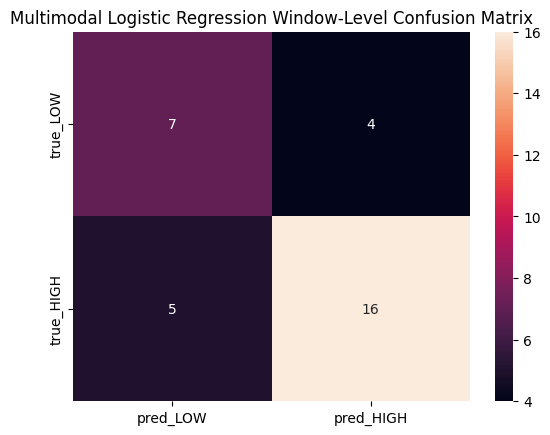

In [28]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(logistic_result["window_confusion_matrix"], annot=True, fmt="d")
plt.title("Multimodal Logistic Regression Window-Level Confusion Matrix")
plt.show()

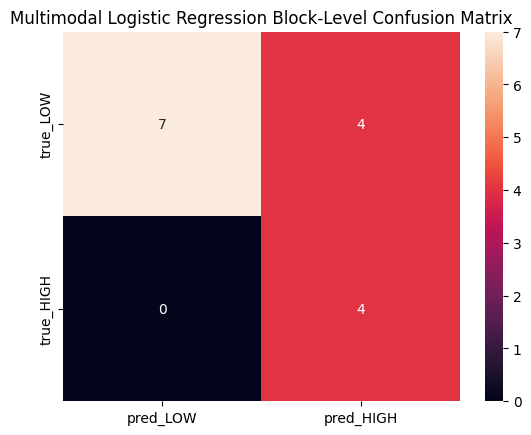

In [29]:
sns.heatmap(logistic_result["block_confusion_matrix"], annot=True, fmt="d")
plt.title("Multimodal Logistic Regression Block-Level Confusion Matrix")
plt.show()

##### Feature Importance Plot

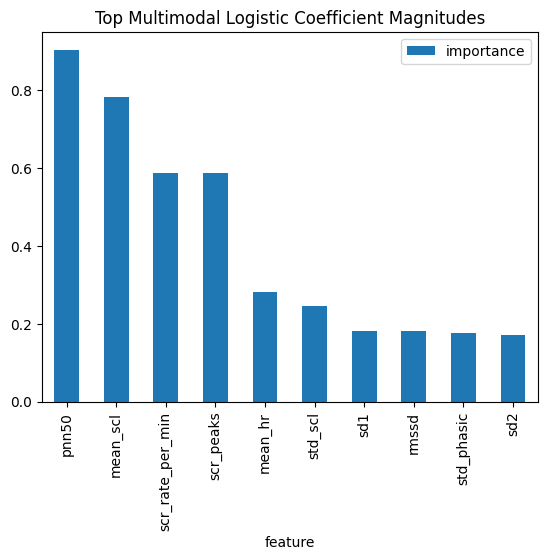

In [30]:
feature_importance.head(10).plot.bar(x="feature")
plt.title("Top Multimodal Logistic Coefficient Magnitudes")
plt.show()

In [31]:
print("Window label counts:")
print(y.value_counts())

print("\nUnique participant-block pairs per label:")
print(modeling_df.groupby("Label").apply(lambda df: df[["Participant", "Block"]].drop_duplicates().shape[0]))

Window label counts:
Label
HIGH    21
LOW     11
Name: count, dtype: int64

Unique participant-block pairs per label:
Label
HIGH     4
LOW     11
dtype: int64


C:\Users\MRUNMAYEE\AppData\Local\Temp\ipykernel_13660\4191236934.py:5: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  print(modeling_df.groupby("Label").apply(lambda df: df[["Participant", "Block"]].drop_duplicates().shape[0]))


In [32]:
# Plain SMOTE is not used here because it ignores participant grouping
# and can create synthetic overlapping windows that leak across folds.
# Prefer class_weight, grouped undersampling, or participant-aware resampling.
